In [6]:
# magic commands to reload custom modules
%load_ext autoreload
%autoreload 2

# magic for matplotlib
%matplotlib notebook

import os
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import uncertainties.unumpy as unp
from uncertainties import ufloat, ufloat_fromstr

from scipy.optimize import curve_fit
from mapp_tricks.peakfit import parse_spectrum_file, plot_plotly, PeakFitter


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
from mapp_tricks.peakfit import parse_spectrum_file, plot_plotly

file2 = parse_spectrum_file('/home/lars/kDrive/uni/phd/projects/dineutron/cs_ana/enrMo100/data/t7A/spectra/10min/000000002.cnf')
print(file2.energy)
pf = PeakFitter()

res = pf.fit_peak(file2, (131,151))
print(res)

fig = plot_plotly(file2, [res])
fig.show()



[1.17590427e-01 3.61454919e-01 6.05319411e-01 ... 1.99712391e+03
 1.99736778e+03 1.99761164e+03]
(1.74+/-0.27)e+03
(4.2+/-0.6)e+02
131.072822406888
131.31668689846992
0.2438644915819168
PeakFitResult(area=1740.8011059569662+/-265.5684183899025, mu=140.7501907972159+/-0.10357526701842817, amp=424.51957664943404+/-64.76270733086734, sigma=0.6451468864609791+/-0.10694208723897186, m=-2.6739931067307294+/-1.2347562416378588, b=2987.5463153560017+/-174.2644596783298, energy_range=(131, 151), energy_bins=array([131.07282241, 131.3166869 , 131.56055139, 131.80441588,
       132.04828037, 132.29214486, 132.53600936, 132.77987385,
       133.02373834, 133.26760283, 133.51146732, 133.75533181,
       133.99919631, 134.2430608 , 134.48692529, 134.73078978,
       134.97465427, 135.21851876, 135.46238326, 135.70624775,
       135.95011224, 136.19397673, 136.43784122, 136.68170571,
       136.9255702 , 137.1694347 , 137.41329919, 137.65716368,
       137.90102817, 138.14489266, 138.38875715, 138.63

In [ ]:
calib = XRayCalibration(level=10, source_radius=0)

In [ ]:
eff = calib.evaluate_efficiency_at(energy_in_keV=ufloat(40, 1))
print(eff)

0.000241+/-0.000011


<IPython.core.display.Javascript object>

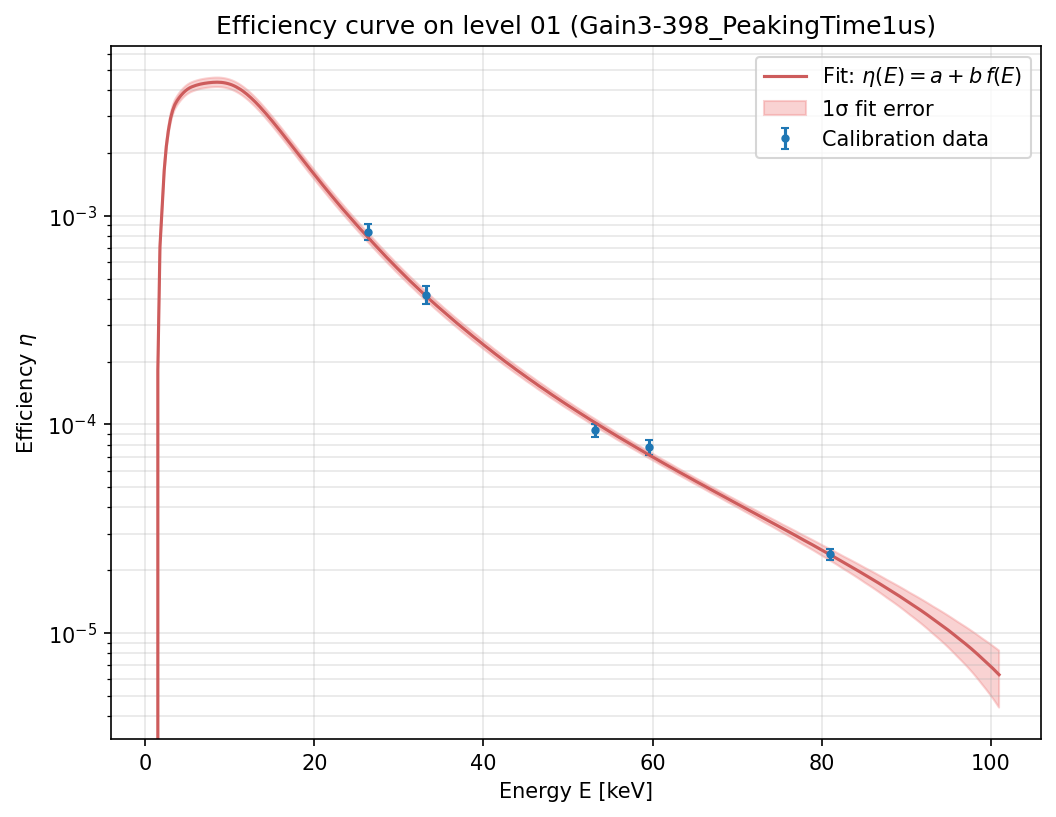

In [32]:
calib.get_plot()

In [2]:
from mapp_tricks.film_analyzer.film_analyzer import  FilmAnalyzer

fa = FilmAnalyzer(
    folder='./data/film_reader_test_data/',
    dpi=1200,
    calibration_key='EBT3_new_METAS_ImageJwRGB',
    plot_downsample=0.5
)


In [3]:
# generate default config and save it to the folder

# config = fa.generate_default_config(
#     default_shape='circular',
#     default_max_dose=10.0,
# )

# fa.save_config(config, fa.folder / 'config.json')

In [4]:
# after generating and editing the config file once, load it like this

config = fa.load_config(fa.folder / 'config.json')

In [6]:
fa.process_all(config, simplify_uncertainty=True)

Processing films:   0%|          | 0/2 [00:00<?, ?file/s]

Processing films:  50%|█████     | 1/2 [00:03<00:03,  3.82s/file]

Saved: DR1mm_01mA_film001.html - ROI mean dose 2.70+/-0.16 Gy (simplify_uncertainty=True)


Processing films: 100%|██████████| 2/2 [00:07<00:00,  3.88s/file]

Saved: DR1mm_03mA_film002.html - ROI mean dose 2.63+/-0.17 Gy (simplify_uncertainty=True)
Summary saved: /home/lars/Nextcloud/Uni/phd/projects/mapp-tricks/playground/data/film_reader_test_data/results/summary.csv (2 entries)
